# Fundamentals 5 · Backpropagation Through a Neuron Chain

A chain of three single neurons (1 → 1 → 1 → 1) predicts a car's fuel economy (mpg) from its weight (lbs),
using `data/auto_mpg.csv`. It is trained with stochastic gradient descent (batch size 1), and
backpropagation computes the partial derivatives. The training data:

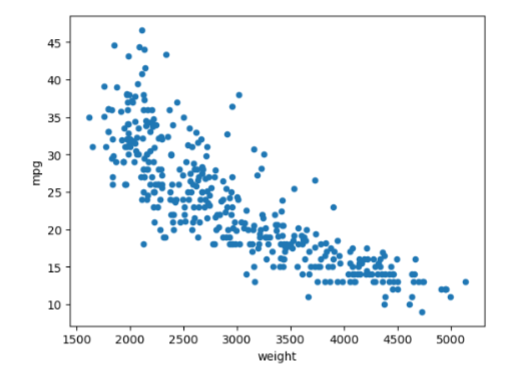

### Design choices

- The input feature is standardized.
- Weights are drawn from a normal distribution with mean 0 and standard deviation $\sqrt{2/n}$ (He
  initialization, suited to ReLU-like activations), where $n$ is the number of inputs; biases start at 0.
- The hidden neurons use Leaky ReLU (slope 0.01 for negative inputs) instead of ReLU, so a neuron whose input
  turns negative still passes some gradient back.
- Learning rate 0.01, 100 epochs.
- Success means beating the simple bias regressor from Fundamentals 3, whose RMSE is roughly the standard
  deviation of the targets. A chain this narrow does not always get there — an unlucky initialization can
  leave it stuck — so the result depends on the random start.

## Implementation

The `Activation`, `SingleLayer` and `Network` classes below are the first version of what became `numpy_nn`.

### Activation functions

In [34]:
from dataclasses import dataclass
from typing import Callable

import numpy as np


def step_function(x: np.ndarray, threshold: float = 0.0) -> np.ndarray:
    return np.where(x >= threshold, 1.0, 0.0)


def sigmoid_function(x: np.ndarray) -> np.ndarray:
    # guarding overflow error
    x = np.clip(x, -60, 60)
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(y: np.ndarray) -> np.ndarray:
    return y * (1 - y)


def relu_function(x: np.ndarray) -> np.ndarray:
    return np.maximum(x, 0.0)


def relu_derivative(y: np.ndarray) -> np.ndarray:
    # relu derivative is step function
    return np.where(y > 0, 1.0, 0.0)

def leaky_relu_function(x: np.ndarray, slope: float = 0.01) -> np.ndarray:
    return np.where(x >= 0, x, slope * x)

def leaky_relu_derivative(y: np.ndarray, slope: float = 0.01) -> np.ndarray:
    # y is the layer's output (post-activation); its sign matches the sign of the pre-activation input
    return np.where(y >= 0, 1.0, slope)

def identity_function(x: np.ndarray) -> np.ndarray:
    return x

def identity_derivative(y: np.ndarray) -> np.ndarray:
    return np.ones_like(y)

@dataclass(frozen=True)
class Activation:
    name: str
    function: Callable[..., np.ndarray]
    derivative: Callable[[np.ndarray], np.ndarray] | None

class ACTIVATIONS:
    STEP = Activation(
        name="step",
        function=step_function,
        derivative=None
    )

    SIGMOID = Activation(
        name="sigmoid",
        function=sigmoid_function,
        derivative=sigmoid_derivative
    )

    RELU = Activation(
        name="relu",
        function=relu_function,
        derivative=relu_derivative
    )

    LEAKY_RELU = Activation(
        name="leaky relu",
        function=leaky_relu_function,
        derivative=leaky_relu_derivative
    )

    IDENTITY = Activation(
        name="identity",
        function=identity_function,
        derivative=identity_derivative
    )

### Layer

In [ ]:
class SingleLayer:
    def __init__(
        self,
        n_inputs: int,
        n_outputs: int,
        activation: Activation
    ):
        self.activation = activation
        self.weights = np.random.normal(0, np.sqrt(2 / n_inputs), (n_outputs, n_inputs))
        self.bias = np.zeros(n_outputs)

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.x = x
        self.z = np.matmul(self.x, self.weights.T) + self.bias
        self.a = self.activation.function(self.z)
        return self.a

    def backward(self, delta: np.ndarray, learning_rate: float) -> np.ndarray:
        if self.activation.derivative is None:
            raise ValueError(f"activation '{self.activation.name}' has no derivative")

        dz = delta * self.activation.derivative(self.a)

        dw = np.outer(dz, self.x)
        db = dz

        propagated = np.matmul(dz, self.weights)

        self.weights -= learning_rate * dw
        self.bias -= learning_rate * db

        return propagated

### Network

In [36]:
class Network:
    def __init__(self, layers: list):
        self.layers = layers

    def forward(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, delta: np.ndarray, learning_rate: float) -> np.ndarray:
        for layer in reversed(self.layers):
            delta = layer.backward(delta, learning_rate)
        return delta

    def predict(self, x_set: np.ndarray) -> np.ndarray:
        return np.array([self.forward(np.array([x]))[0] for x in x_set])

    def loss(self, y: np.ndarray, y_pred: np.ndarray) -> float:
        return np.mean((y - y_pred) ** 2)

    def loss_derivative(self, y: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        return -1.0 * (2.0 / y.size) * (y - y_pred)

### Model

In [37]:
INPUT_SIZE = 1
OUTPUT_SIZE = 1

hidden_layer1 = SingleLayer(INPUT_SIZE, 1, ACTIVATIONS.LEAKY_RELU)
hidden_layer2 = SingleLayer(1, 1, ACTIVATIONS.LEAKY_RELU)
output_layer = SingleLayer(1, OUTPUT_SIZE, ACTIVATIONS.IDENTITY)

model = Network([
    hidden_layer1,
    hidden_layer2,
    output_layer
])

### Reading the data

In [38]:
from pathlib import Path

# the repository root is the first folder above this notebook that holds pyproject.toml
REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
DATA_DIR = REPO_ROOT / "data"

import pandas as pd

df = pd.read_csv(DATA_DIR / "auto_mpg.csv")

weight = df["weight"].to_numpy(dtype=float)
mpg = df["mpg"].to_numpy(dtype=float)

# standardize the input feature
weight_mean = weight.mean()
weight_std = weight.std()
weight_norm = (weight - weight_mean) / weight_std

x_set = weight_norm
y_set = mpg

### Baseline RMSE

In [39]:
baseline = y_set.mean()
baseline_set = np.full_like(y_set, baseline)
baseline_mse = model.loss(y_set, baseline_set)
baseline_rmse = np.sqrt(baseline_mse)

print(f"baseline RMSE (simple bias regressor): {baseline_rmse}")

baseline RMSE (simple bias regressor): 7.795045762682584


### Training

In [40]:
LEARNING_RATE = 0.01
EPOCHS = 100

def train() -> None:
    for epoch in range(EPOCHS):
        for x, y in zip(x_set, y_set):
            x_input = np.array([x])
            y_true = np.array([y])

            y_pred = model.forward(x_input)

            delta = model.loss_derivative(y_true, y_pred)
            model.backward(delta, LEARNING_RATE)

        epoch_num = epoch + 1

        if epoch_num == 1 or epoch_num % 10 == 0:
            train_rmse = np.sqrt(model.loss(y_set, model.predict(x_set)))
            print(f"epoch {epoch_num}: train RMSE = {train_rmse}")

### Results

The chain beats the baseline: its RMSE falls from 10.6 after the first epoch to 5.8, against 7.8 for always
predicting the mean.

In [41]:
train()

final_rmse = np.sqrt(model.loss(y_set, model.predict(x_set)))

print()
print(f"final RMSE:    {final_rmse:.4f}")
print(f"baseline RMSE: {baseline_rmse:.4f}")

if final_rmse > baseline_rmse:
    print("\nmodel does not beat baseline")
else:
    print("\nmodel beats baseline")

epoch 1: train RMSE = 10.6071380135202
epoch 10: train RMSE = 6.549502956151606
epoch 20: train RMSE = 5.516801586511946
epoch 30: train RMSE = 5.865307364654873
epoch 40: train RMSE = 5.884332231143895
epoch 50: train RMSE = 5.882963233402055
epoch 60: train RMSE = 5.879389910102666
epoch 70: train RMSE = 5.869296004837244
epoch 80: train RMSE = 5.853477562896166
epoch 90: train RMSE = 5.818783439331582
epoch 100: train RMSE = 5.815872951152844

final RMSE:    5.8159
baseline RMSE: 7.7950

model beats baseline
